Definition of LangGraph's state `GraphState`: `question` - User's question; `messages` - Application's generation; `documents` - The list of relevant documents

In [22]:
from langchain_core.documents import Document
from typing import List
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name='gpt-4o', temperature=0)

class GraphState(TypedDict):
  question: str
  documents: List[str]
  messages: List[str]

Definiton of Tavily Client for web search

In [23]:
from tavily import TavilyClient
import os

tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

Definition of the LLM Prompt

In [24]:
prompt = """You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question}

Context: {context}

Answer:"""
print(f"Prompt template: {prompt}")

Prompt template: You are a professor and expert in explaining complex topics in a way that is easy to understand. 
Your job is to answer the provided question so that even a 5 year old can understand it. 
You have provided with relevant background context to answer the question.

Question: {question}

Context: {context}

Answer:


In [25]:
from langchain_core.messages import HumanMessage

def search(state: GraphState):
  """
  Web search based on the re-phrased question.

  Args:
    state (dict): The current graph's state

  Returns:
    state (dict): Updates documents key with appended web results
  """

  question = state["question"]
  documents = state.get("documents", [])

  # Web Search
  web_docs = tavily.search(query=question, max_results=2)
  web_results = "\n".join([d["content"] for d in web_docs["results"]])
  web_results = Document(page_content=web_results)
  documents.append(web_results)

  return {"documents": documents, "question": question}

def explain(state: GraphState):
  """
  Generate response

  Args:
    state (dict): The current graph state

  Returns:
    state (dict): New key added to state, generation, that contains LLM generation
  """
  question = state["question"]
  documents = state.get("documents", [])
  formatted = prompt.format(question=question, context="\n".join([d.page_content for d in documents]))
  generation = llm.invoke([HumanMessage(content=formatted)])

  return {"question": question, "messages": [generation]}

Init Graph, nodes and edges

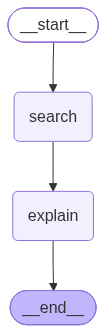

In [26]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(GraphState)
graph.add_node("search", search)
graph.add_node("explain", explain)
graph.add_edge(START, "search")
graph.add_edge("search", "explain")
graph.add_edge("explain", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

Pretify output results function

In [27]:
def ask(question: str):
  for output in app.stream({"question": question}, stream_node="updates"):
    if END in output or START in output:
      continue
    # Print any node outputs
    for key, value in output.items():
      if "messages" in value:
        print(value["messages"][0].content)

Execution

In [ ]:
question = 'What is the difference between N8N and LangGraph'
ask(question)

Okay, imagine you have two different kinds of toys to play with. One toy is like a set of colorful building blocks that you can easily snap together to make simple things, like a little house or a car. This toy is called n8n. It's great for when you want to quickly build something fun without needing to know a lot about how it works inside. You just connect the pieces, and voilà, you have something cool!

The other toy is like a big, fancy robot kit that lets you build a robot that can do lots of different things, like talk to you or remember what you said before. This toy is called LangGraph. It's a bit more complicated and you need to know how to follow special instructions to make it work. But once you learn how, you can make really amazing robots that can think and do lots of smart things.

So, if you want to build something simple and fast, you might choose the building blocks (n8n). But if you want to create a super-smart robot that can do lots of things, you might pick the robot